In [13]:
import os
import numpy as np
import nibabel as nib
from scipy.spatial.distance import pdist
from tqdm import tqdm

from t_testing.clean_roi_mask import modify_mask_with_ttest
import nibabel as nib
import pandas as pd
import logging

from utils.config import Configuration, load_config
from utils.utils import retrieve_stacked_betas
from previousCode.nsddatapaper_rsa.utils.utils import mds

from scipy.stats import wasserstein_distance

# Define custom metric wrapper
def emd(u, v):
    return wasserstein_distance(u, v)

def create_rdm_with_all_trials(
    config: Configuration,
    subj_list,
    mask_value,
    set_to_take,
    t_test_threshold,
    randomization=False
):
    """
    For each subject, load all 3 trials per image (so 150 images ⇒ 450 patterns),
    apply your ROI mask, compute the pairwise RDM (450×450) and MDS coords (450×2).

    Returns
    -------
    results : dict
        { sub : {
            'rdm'      : 1D array of length 450*449/2,
            'mds'      : array (450,2),
            'meta'     : list of (image_id, trial_idx) for each of the 450 rows
          }
        }
    """
    results = {}

    for sub in tqdm(subj_list, desc="Subjects"):
        # 1) Make t-test mask
        pick_shared = (set_to_take == "shared")
        modify_mask_with_ttest(
            config, t_test_threshold, pick_shared, sub, sub_filename="temporary_mask"
        )

        # 2) Load and concatenate LH & RH mask arrays
        roi_dir = config.directories.t_test_roi_dir
        mask_lh = nib.load(os.path.join(roi_dir, set_to_take, f"lh.subj{sub:02d}.temporary_mask.mgz")).get_fdata().squeeze()
        mask_rh = nib.load(os.path.join(roi_dir, set_to_take, f"rh.subj{sub:02d}.temporary_mask.mgz")).get_fdata().squeeze()
        combined_mask = np.concatenate((mask_lh, mask_rh)).astype(int)
        # build a boolean mask of the voxels we want
        vox_selector = (combined_mask == mask_value) if isinstance(mask_value, int) else np.isin(combined_mask, mask_value)
        vox_selector = vox_selector.flatten()

        # 3) Retrieve and stack all three trials
        all_patterns = []
        meta = []   # to store (image_id, trial_idx)
        for trial_idx in range(3):
            betas, image_ids, _ = retrieve_stacked_betas(
                config,
                sub,
                "single",           # single ⇒ one trial at a time
                trial_idx,
                subj_to_check=set_to_take,
                only_face_set=config.pipeline.step_4_rsa_analysis.only_face_set,
                randomization=randomization
            )
            # betas is shape (n_images, V); we want (V, n_images) then transpose to (n_images, V)
            betas = betas.T  # now shape V × 150
            betas = betas.T  # shape (150, V)
            all_patterns.append(betas)
            # replicate image_ids for this trial
            meta += [(img, trial_idx) for img in image_ids]

        # stack into (450, V)
        X450 = np.vstack(all_patterns)  

        # 4) apply the voxel mask and drop any NaNs
        X450_masked = X450[:, vox_selector]
        good_rows = ~np.isnan(X450_masked).any(axis=1)
        X450_masked = X450_masked[good_rows, :]
        meta = [m for keep, m in zip(good_rows, meta) if keep]

        # 5) compute RDM and MDS
        dm = config.pipeline.step_4_rsa_analysis.distance_metric
        metric_fn = emd if dm == "wasserstein" else dm
        rdm_vec = pdist(X450_masked, metric=metric_fn)
        mds_coords = mds(rdm_vec).astype(np.float32)

        # 6) store
        results[sub] = {
            'rdm':    rdm_vec,
            'mds':    mds_coords,
            'meta':   meta
        }

    return results


In [14]:
config = load_config("config.yaml")

results = create_rdm_with_all_trials(
    config,
    subj_list=[1],
    mask_value=7,
    set_to_take="subj_01",
    t_test_threshold=2.5,
    randomization=False
)


Subjects:   0%|          | 0/1 [00:00<?, ?it/s]2025-05-20 16:37:23 INFO: Processing subject 1 with threshold 2.5
2025-05-20 16:37:23 INFO: ROI 1: majority positive (pos=8096, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 2: majority positive (pos=2086, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 3: majority positive (pos=3810, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 4: majority positive (pos=880, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 5: majority positive (pos=965, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 6: majority negative (pos=0, neg=5919) - keeping voxels with t <= -2.5
2025-05-20 16:37:23 INFO: ROI 7: majority positive (pos=2567, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 8: majority positive (pos=4084, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:23 INFO: ROI 9: majority negative (pos=501, neg=4120) - keeping voxels 

In [15]:
results

{1: {'rdm': array([0.86820504, 1.10862807, 0.79441584, ..., 0.85011519, 0.90104437,
         0.92779471]),
  'mds': array([[-0.5487505 , -0.05557047],
         [ 0.46466467, -0.11631727],
         [ 0.5262773 ,  0.62498593],
         ...,
         [-0.6687357 ,  0.206138  ],
         [-0.65724045,  0.20256278],
         [ 0.4776587 , -0.41583696]], dtype=float32),
  'meta': [('000000531961', 0),
   ('000000104543', 0),
   ('000000303485', 0),
   ('000000343543', 0),
   ('000000198308', 0),
   ('000000459151', 0),
   ('000000152036', 0),
   ('000000407298', 0),
   ('000000048417', 0),
   ('000000495166', 0),
   ('000000175251', 0),
   ('000000568630', 0),
   ('000000134738', 0),
   ('000000552461', 0),
   ('000000365404', 0),
   ('000000112208', 0),
   ('000000087864', 0),
   ('000000037852', 0),
   ('000000124766', 0),
   ('000000416157', 0),
   ('000000069559', 0),
   ('000000470541', 0),
   ('000000383263', 0),
   ('000000207521', 0),
   ('000000218093', 0),
   ('000000235031', 0),
 

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mds_embedding(mds_coords, meta, subject_id=None):
    """
    Scatter‐plot the MDS embedding for all trials.
    
    Parameters
    ----------
    mds_coords : np.ndarray, shape (N, 2)
        The 2D MDS coordinates for N samples (e.g., 450 = 150 images × 3 trials).
    meta : list of tuples
        List of (image_id, trial_index) for each of the N samples.
    subject_id : int or str, optional
        Identifier to include in the plot title.
    """
    # Extract image IDs to use as the color values
    image_ids = np.array([m[0] for m in meta])
    
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(mds_coords[:, 0], mds_coords[:, 1], c=image_ids)
    plt.xlabel("MDS Dimension 1")
    plt.ylabel("MDS Dimension 2")
    title = "MDS Embedding (All Trials)"
    if subject_id is not None:
        title += f" – Subject {subject_id}"
    plt.title(title)
    plt.colorbar(sc, label="Image ID")
    plt.show()





In [17]:
# Example usage:
results = create_rdm_with_all_trials(
    config,
    subj_list=[1],
    mask_value=7,
    set_to_take="subj_01",
    t_test_threshold=2.5,
)




Subjects:   0%|          | 0/1 [00:00<?, ?it/s]2025-05-20 16:37:30 INFO: Processing subject 1 with threshold 2.5
2025-05-20 16:37:30 INFO: ROI 1: majority positive (pos=8096, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 2: majority positive (pos=2086, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 3: majority positive (pos=3810, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 4: majority positive (pos=880, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 5: majority positive (pos=965, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 6: majority negative (pos=0, neg=5919) - keeping voxels with t <= -2.5
2025-05-20 16:37:30 INFO: ROI 7: majority positive (pos=2567, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 8: majority positive (pos=4084, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:37:30 INFO: ROI 9: majority negative (pos=501, neg=4120) - keeping voxels 

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, Dropdown

def interactive_mds_plot(mds_coords, meta, subject_id=None):
    """
    Interactive scatter‐plot of the MDS embedding for all trials,
    with dropdown to select an image ID and connect its 3 trials.
    
    Parameters
    ----------
    mds_coords : np.ndarray, shape (N, 2)
        The 2D MDS coordinates for N samples (e.g., 450 = 150 images × 3 trials).
    meta : list of tuples
        List of (image_id, trial_index) for each of the N samples.
    subject_id : int or str, optional
        Identifier to include in the plot title.
    """
    image_ids = np.array([m[0] for m in meta])
    coords = mds_coords
    
    unique_ids = sorted(set(image_ids))

    def plot(image_id):
        plt.figure(figsize=(8, 6))
        # plot all points lightly
        plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3)
        
        # highlight selected image's trials
        sel_mask = image_ids == image_id
        sel_coords = coords[sel_mask]
        plt.scatter(sel_coords[:, 0], sel_coords[:, 1], s=100)
        
        # connect the 3 points in a triangle (closed loop)
        loop = np.vstack([sel_coords, sel_coords[0]])
        plt.plot(loop[:, 0], loop[:, 1], linestyle='-')
        
        plt.xlabel("MDS Dimension 1")
        plt.ylabel("MDS Dimension 2")
        title = "MDS Embedding (All Trials)"
        if subject_id is not None:
            title += f" – Subject {subject_id}"
        plt.title(title)
        plt.show()

    interact(plot, image_id=Dropdown(options=unique_ids, description="Image ID"))



import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

def animate_mds_loop(mds_coords, meta, subject_id=None, interval=2.0):
    """
    Continuously animate the MDS embedding, cycling through image IDs every `interval` seconds.
    
    Parameters
    ----------
    mds_coords : np.ndarray, shape (N, 2)
        The 2D MDS coordinates for N samples (e.g., 450 = 150 images × 3 trials).
    meta : list of tuples
        List of (image_id, trial_index) for each of the N samples.
    subject_id : int or str, optional
        Identifier to include in the plot title.
    interval : float
        Time in seconds between frames.
    """
    image_ids = np.array([m[0] for m in meta])
    coords = mds_coords
    unique_ids = sorted(set(image_ids))
    idx = 0

    try:
        while True:
            image_id = unique_ids[idx]
            clear_output(wait=True)
            plt.figure(figsize=(8, 6))
            # plot all trials lightly
            plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3)
            # highlight the three trials for the current image
            sel = image_ids == image_id
            sel_coords = coords[sel]
            plt.scatter(sel_coords[:, 0], sel_coords[:, 1], s=100)
            # draw triangle
            tri = np.vstack([sel_coords, sel_coords[0]])
            plt.plot(tri[:, 0], tri[:, 1])
            plt.xlabel("MDS Dimension 1")
            plt.ylabel("MDS Dimension 2")
            title = f"MDS Embedding (All Trials)"
            if subject_id is not None:
                title += f" – Subject {subject_id}"
            title += f" | Highlight: Image ID {image_id}"
            plt.title(title)
            plt.show()
            idx = (idx + 1) % len(unique_ids)
            time.sleep(interval)
    except KeyboardInterrupt:
        clear_output(wait=True)
        print("Animation stopped.")

# Usage example inside a notebook cell:
# animate_mds_loop(mds_coords, meta, subject_id=1, interval=2.0)



In [19]:
subject = 1
mds_coords = results[subject]["mds"]
meta = results[subject]["meta"]

animate_mds_loop(mds_coords, meta, subject_id=subject)

Animation stopped.


Subjects:   0%|          | 0/1 [00:00<?, ?it/s]2025-05-20 16:46:06 INFO: Processing subject 1 with threshold 2.5
2025-05-20 16:46:06 INFO: ROI 1: majority positive (pos=8096, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 2: majority positive (pos=2086, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 3: majority positive (pos=3810, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 4: majority positive (pos=880, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 5: majority positive (pos=965, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 6: majority negative (pos=0, neg=5919) - keeping voxels with t <= -2.5
2025-05-20 16:46:06 INFO: ROI 7: majority positive (pos=2567, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 8: majority positive (pos=4084, neg=0) - keeping voxels with t >= 2.5
2025-05-20 16:46:06 INFO: ROI 9: majority negative (pos=501, neg=4120) - keeping voxels 

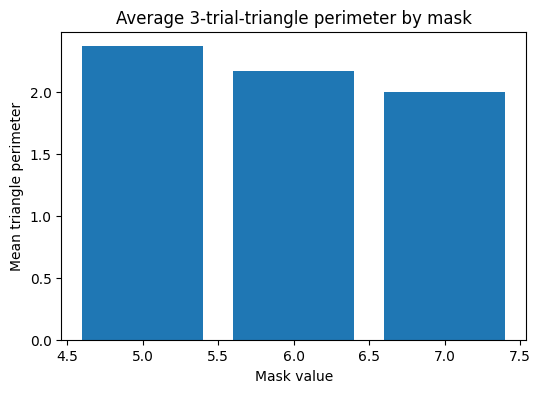

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mask_values = [1,2,3,4,5, 6, 7]
avg_perimeters = []

for mv in mask_values:
    # compute RDM+MDS for this mask
    results = create_rdm_with_all_trials(
        config,
        subj_list=[1],
        mask_value=mv,
        set_to_take="subj_01",
        t_test_threshold=2.5
    )
    # unpack for subject 1
    mds_coords = results[1]['mds']   # shape (450,2)
    meta       = results[1]['meta']  # list of (image_id, trial_index)

    perimeters = []
    for img in sorted({m for m, _ in meta}):
        # find the three rows for this image
        idxs = [i for i, (m, t) in enumerate(meta) if m == img]
        pts = mds_coords[idxs]  # (3, 2)
        # compute the three side‐lengths
        d01 = np.linalg.norm(pts[0] - pts[1])
        d12 = np.linalg.norm(pts[1] - pts[2])
        d20 = np.linalg.norm(pts[2] - pts[0])
        perimeters.append(d01 + d12 + d20)

    avg_perimeters.append(np.mean(perimeters))

# now compare across masks
plt.figure(figsize=(6,4))
plt.bar(mask_values, avg_perimeters)
plt.xlabel("Mask value")
plt.ylabel("Mean triangle perimeter")
plt.title("Average 3-trial-triangle perimeter by mask")
plt.show()
